In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

from imblearn.under_sampling import RandomUnderSampler

sns.set_theme()

Sources:

`a.csv` : [First Dataset](https://www.kaggle.com/datasets/prishasawhney/email-classification-ham-spam)

`b.csv` : [Second Dataset](https://www.kaggle.com/datasets/tapakah68/email-spam-classification)

`c.csv` : [Third Dataset](https://www.kaggle.com/datasets/nitishabharathi/email-spam-dataset/data)

`d.csv` : [Fourth Dataset](https://www.kaggle.com/datasets/abdmental01/email-spam-dedection)

`e.csv` : [Fifth Dataset](https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset)

`f.csv` : [Sixth Dataset](https://www.kaggle.com/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification)

In [2]:
def load_a():
    data=pd.read_csv('a.csv')
    data=data.rename(columns={'email': 'text'}).replace({'label': {'spam': 1, 'ham': 0}})
    return data

def load_b():
    data=pd.read_csv('b.csv')
    data=data.replace({'label': {'spam': 1, 'not spam': 0}})
    return data

def load_c():
    data=pd.read_csv('c.csv', usecols=['text', 'label'], na_values={'text': ['empty', np.nan]})
    data=data.dropna()
    data=data.loc[data['label'].isin(['1', '0']), :]
    data['label']=data['label'].astype(int)
    return data

def load_d():
    data=pd.read_csv('d.csv')
    data=data.replace({'label': {'spam': 1, 'ham': 0}})
    return data

def load_e():
    data=pd.read_csv('e.csv')
    return data

def load_f():
    data=pd.read_csv('f.csv')
    data=data.dropna().replace({'label': {'Spam': 1, 'Ham': 0}})
    return data

def sample_points(n, dataset, random_state=None):
    dataset=dataset.sample(frac=1.0, random_state=random_state)
    label_index=(dataset['label']==1)
    label1=dataset.loc[label_index, :].iloc[:n, :]
    label0=dataset.loc[~label_index, :].iloc[:n, :]
    return pd.concat((label1, label0), ignore_index=True)


def combine_datasets(combinations, balance_dataset=False, include_points=1000, random_state=None):
    loaders=[load_a, load_b, load_c, load_d, load_e, load_f]
    data=None
    for i in combinations:
        if data is None:
            data=sample_points(include_points, loaders[i-1](), random_state)
        else:
            subset=sample_points(include_points, loaders[i-1](), random_state)
            data=pd.concat((data, subset), ignore_index=True)
    if balance_dataset:    
        sampler=RandomUnderSampler(random_state=random_state)
        return sampler.fit_resample(data, data['label'])[0]
    
    return data
    

In [3]:
data=combine_datasets([1, 2, 4, 5], include_points=500, random_state=29)
data

,text,label
0,Your account has been credited with bonus poin...,1
1,Claim your prize now! Click here to confirm yo...,1
2,Your bank account has been suspended. Click he...,1
3,Get rich quick! Click here to join our exclusi...,1
4,Unlock exclusive discounts! Click here to join...,1
...,...,...
2258,escapenumberd escapenumberd escapenumberd esc...,0
2259,i believe when you run cygwin it maps the dire...,0
2260,howstuffworks r science technology april escap...,0
2261,i want to produce stacked histograms where the...,0


In [4]:
X, y=data['text'], data['label']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25)
count_vec=CountVectorizer(stop_words='english')
count_vec.fit(X_train, y_train)

CountVectorizer(stop_words='english')

In [5]:
X_train_, X_test_=count_vec.transform(X_train), count_vec.transform(X_test)
X_train_

<1697x21790 sparse matrix of type '<class 'numpy.int64'>'
	with 76860 stored elements in Compressed Sparse Row format>

In [6]:
class NaiveBayes:
    def __init__(self, prior=0):
        self.p=prior
        self.p1=None
        self.p0=None
    
    def estimate_params(self, X, y):
        subset_index=(y==0)
        return np.array((X[subset_index, :]>0).mean(axis=0))[0], np.array((X[~subset_index, :]>0).mean(axis=0))[0]

    def add_smoothing(self, X, y):
        n_features=X.shape[1]
        empty=sparse.csr_matrix(0, shape=(1, n_features))
        full=sparse.csr_matrix(1, shape=(1, n_features))
        new_data_matrix=sparse.vstack((X, empty, empty.copy(), full, full.copy()))
        new_labels=np.concatenate((y, [0, 1, 0, 1]))
        return new_data_matrix, new_labels

    def fit(self, X, y):
        X_new, y_new=self.add_smoothing(X, y)
        if self.p==0:
            self.p=(y_new==1).mean()
        self.p0, self.p1=self.estimate_params(X_new, y_new)
        self.p0[self.p0==0]=1e-6
        self.p1[self.p1==0]=1e-6
        return self
    
    def predict(self, X):
        X_new=(X>0).astype(int)
        predictions= X_new @ np.log( (self.p1 * (1-self.p0))  /  (self.p0 * (1-self.p1)) )
        predictions+= np.sum( np.log( (1-self.p1) / (1-self.p0) ) ) + np.log( self.p/(1-self.p) )
        return (predictions>=0).astype(int)


# Logistic Regression

In [36]:
class LogReg:
    def __init__(self, iterations, step_size):
        self.iterations=iterations
        self.step_size=step_size
        self.coef_=None
        self.errors=[]
    
    def sigmoid(self, z):
        return 1/(1+ np.exp(-z))

    def loss(self, X, y):
        probs= self.sigmoid(X @ self.coef_)
        return -(y*np.log(probs) + (1-y)*np.log(1-probs)).mean()

    def gradient(self, X, y):
        y_hat=self.sigmoid(X @ self.coef_)
        differences=y_hat-y
        return np.array((sparse.diags(differences) @ X).sum(axis=0))[0]
    
    def gradient_descent(self, X, y):
        self.coef_=np.zeros(X.shape[1])
        for i in range(self.iterations):
            grad=self.gradient(X, y)
            self.coef_-=self.step_size*grad
            self.errors.append(self.loss(X, y))

    def normalize(self, X):
        return (X@sparse.diags((np.array(X.power(2).sum(axis=0))[0]+1)**-0.5))

    def fit(self, X, y):
        self.gradient_descent(self.normalize(X), y)
        return self
    
    def predict(self, X):
        probs=self.normalize(X) @ self.coef_
        return (probs>=0).astype(int)        
        

# Model Evaluation and Comparison

In [63]:
def evaluate_model(model, vectorizer):
    loaders=[load_a, load_b, load_c, load_d, load_e, load_f]
    result={}
    for i in range(len(loaders)):
        dataset=loaders[i]()
        X, y = vectorizer.transform(dataset['text']), dataset['label']
        predictions=model.predict(X)
        accuracy=(predictions==y).mean()*100
        result['Dataset %d'%(i+1)]=accuracy
        print('-------')
        print('\tAccuracy on Dataset %d : %.3f'%(i+1, accuracy))
        print('\tSpam %% : %.3f'%(y.mean()*100))
        print('\tSize : %d'%X.shape[0])
        print('-------')
    return pd.Series(result)

## function to generate splits in cross validation
def genrate_splits(n, test_size, random_seed=None):
   rng=np.random.default_rng(seed=random_seed)
   index=np.arange(n)
   sorted_index=index.copy()
   rng.shuffle(index)
   factor=int(n*test_size)+1
   iterations=0
   while (factor*iterations < index.shape[0]):
      test_index=(sorted_index>=iterations*factor) & (sorted_index<(iterations+1)*factor)
      train_index=~test_index
      yield index[train_index], index[test_index]
      iterations+=1
   

## function to run cross validation on a model
def cross_validate(X, y, model, test_size, random_seed=None):
   iterations=0
   accuracy=0
   for train_index, validation_index in genrate_splits(X.shape[0], test_size, random_seed):
      X_train, X_valid, y_train, y_valid=X[train_index, :], X[validation_index, :], y[train_index], y[validation_index]
      model.fit(X_train, y_train)
      predictions=model.predict(X_valid)
      accuracy+=(predictions==y_valid).mean()*100
      iterations+=1

   return accuracy/iterations

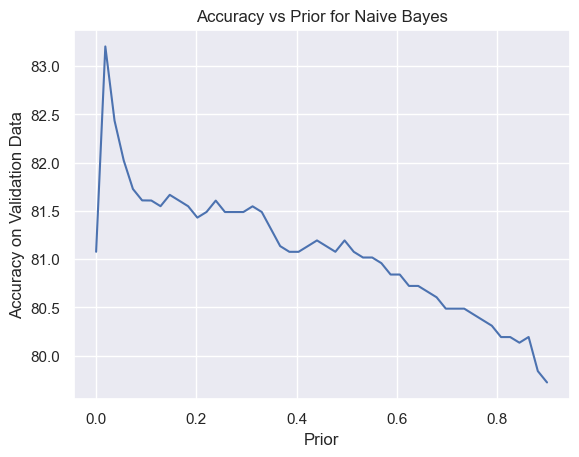

In [64]:
priors = np.linspace(0, 0.9, 50)
accuracies=[]
for prior in priors:
    accuracies.append(cross_validate(X_train_, y_train.values, NaiveBayes(prior), 0.25, random_seed=7))

plt.plot(priors, accuracies)
plt.xlabel('Prior')
plt.ylabel('Accuracy on Validation Data')
plt.title('Accuracy vs Prior for Naive Bayes')
plt.show()

In [65]:
best_proir=priors[np.argmax(accuracies)]
nb=NaiveBayes(prior=best_proir)
nb.fit(X_train_, y_train)
predictions=nb.predict(X_train_)
accuracy=(predictions==y_train).mean()*100
print('Naive Bayes')
print('Training Data Accuracy : %.3f'%accuracy)
predictions=nb.predict(X_test_)
accuracy=(predictions==y_test).mean()*100
print('Testing Data Accuracy : %.3f'%accuracy)
print('------------------------------------')
print()

Naive Bayes
Training Data Accuracy : 97.938
Testing Data Accuracy : 85.866
------------------------------------



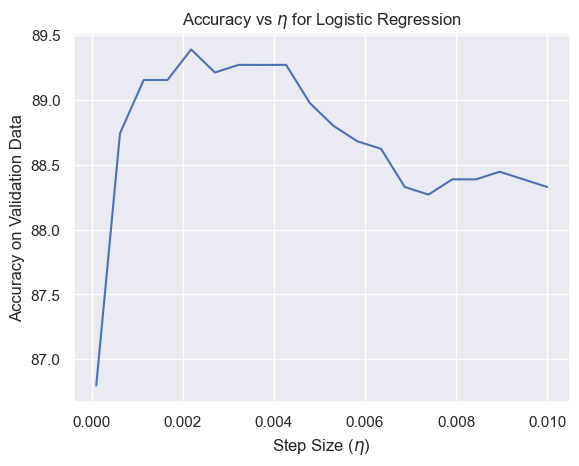

In [66]:
rates = np.linspace(0.0001, 0.01, 20)
accuracies=[]
for rate in rates:
    accuracies.append(cross_validate(X_train_, y_train.values, LogReg(1000, rate), 0.25, random_seed=5))

plt.plot(rates, accuracies)
plt.xlabel('Step Size ($\eta$)')
plt.ylabel('Accuracy on Validation Data')
plt.title('Accuracy vs $\eta$ for Logistic Regression')
plt.show()

In [67]:
best_rate=rates[np.argmax(accuracies)]
log_reg=LogReg(1000, best_rate)
log_reg.fit(X_train_, y_train.values)

predictions=log_reg.predict(X_train_)
accuracy=(predictions==y_train).mean()*100
print('Logistic Regression')
print('Training Data Accuracy : %.3f'%accuracy)
predictions=log_reg.predict(X_test_)
accuracy=(predictions==y_test).mean()*100
print('Testing Data Accuracy : %.3f'%accuracy)
print('------------------------------------')
print()

Logistic Regression
Training Data Accuracy : 98.586
Testing Data Accuracy : 88.869
------------------------------------



In [68]:
X_=count_vec.fit_transform(X)
nb.fit(X_, y)
log_reg.fit(X_, y.values)

In [69]:
print('Naive Bayes')
result_nb=evaluate_model(nb, count_vec)

Naive Bayes
-------
	Accuracy on Dataset 1 : 83.240
	Spam % : 44.134
	Size : 179
-------
-------
	Accuracy on Dataset 2 : 97.619
	Spam % : 30.952
	Size : 84
-------
-------
	Accuracy on Dataset 3 : 86.031
	Spam % : 28.252
	Size : 5412
-------
-------
	Accuracy on Dataset 4 : 68.665
	Spam % : 13.406
	Size : 5572
-------
-------
	Accuracy on Dataset 5 : 89.996
	Spam % : 52.620
	Size : 83448
-------
-------
	Accuracy on Dataset 6 : 86.900
	Spam % : 47.300
	Size : 193850
-------


In [70]:
print('Logistic Regression')
result_lr=evaluate_model(log_reg, count_vec)

Logistic Regression
-------
	Accuracy on Dataset 1 : 89.385
	Spam % : 44.134
	Size : 179
-------
-------
	Accuracy on Dataset 2 : 96.429
	Spam % : 30.952
	Size : 84
-------
-------
	Accuracy on Dataset 3 : 84.239
	Spam % : 28.252
	Size : 5412
-------
-------
	Accuracy on Dataset 4 : 85.696
	Spam % : 13.406
	Size : 5572
-------
-------
	Accuracy on Dataset 5 : 91.210
	Spam % : 52.620
	Size : 83448
-------
-------
	Accuracy on Dataset 6 : 86.467
	Spam % : 47.300
	Size : 193850
-------


Text(0.5, 1.0, 'Naive Bayes   vs   Logistic Regression')

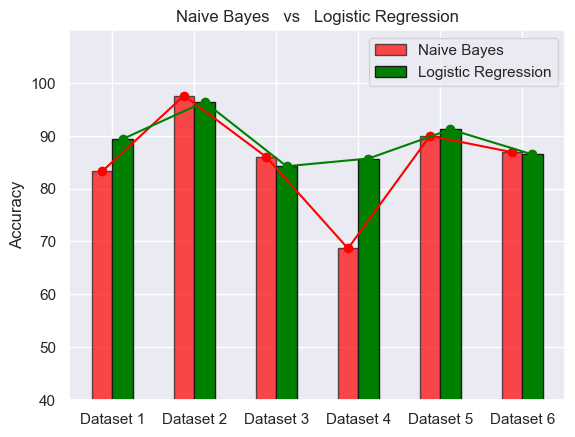

In [71]:
ax=plt.axes()
x=np.arange(6)
width=0.25

ax.bar(x-width, result_nb, width, align='edge', color='red', label='Naive Bayes', alpha=0.7, edgecolor='k')
ax.bar(x, result_lr, width, align='edge', color='Green', label='Logistic Regression', edgecolor='k')

ax.plot(x-width/2, result_nb, marker='o', color='red', )
ax.plot(x+width/2, result_lr, marker='o', color='green',)
ax.legend()

ax.set_ylim(bottom=40, top=110)
ax.set_yticks(ax.get_yticks()[:-1])

ax.set_xticks(x)
ax.set_xticklabels(result_lr.index)

ax.set_ylabel('Accuracy')
ax.set_title('Naive Bayes   vs   Logistic Regression')


In [72]:
log_reg.predict(count_vec.transform(["Hello, A user just logged into your Facebook account from a NEW device. Device: iPhone 14 Pro.Location: Kolkata, India We are sending you this email to verify it's really you."]))

array([0])

In [73]:
log_reg.predict(count_vec.transform(["Hey there your lottery number is 421020, click here to redeem the amount!!"]))

array([1])

In [81]:
log_reg.predict(count_vec.transform(["Money will be sent to your bank account.!!"]))
# log_reg.predict(count_vec.transform([""]))

array([1])

In [166]:
np.char.add('email', np.arange(1, 20).astype(dtype=np.dtype('<U5')))

array(['email1', 'email2', 'email3', 'email4', 'email5', 'email6',
       'email7', 'email8', 'email9', 'email10', 'email11', 'email12',
       'email13', 'email14', 'email15', 'email16', 'email17', 'email18',
       'email19'], dtype='<U10')

In [85]:
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier

svm=SVC(kernel='rbf')
svm.fit(X_train_, y_train)

SVC()

In [83]:
svm.score(X_train_, y_train)

0.6564525633470831

In [84]:
svm.score(X_test_, y_test)

0.6607773851590106